#agentlab_vllm.ipynb

<ul>
<li>vLLM AgentLab</li>
<li>Verify MIN L4 GPU or get error message below FA version 2 (T4)</li>
<li></li>
<li></li>

</ul>

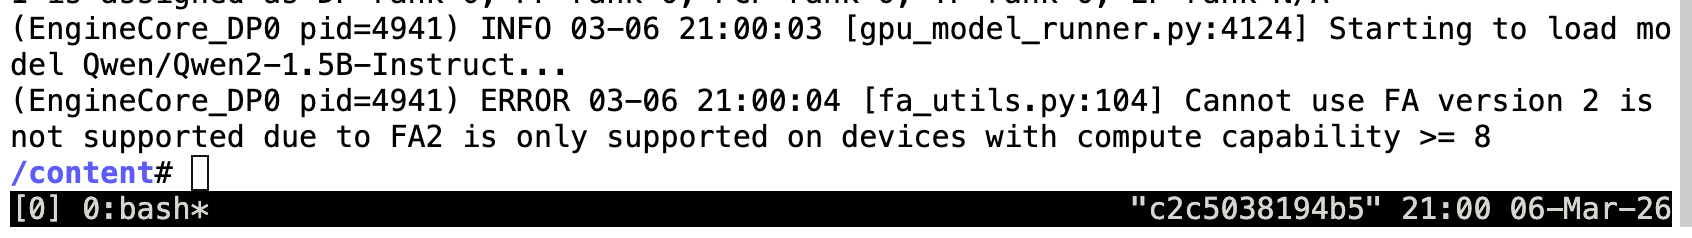

In [8]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [7]:
# copy models from /drive/MyDrive/'Colab Notebooks'/.cache/huggingface to /root/.cache
#gigs will take a while
%cp -r /content/drive/MyDrive/'Colab Notebooks'/.cache/huggingface /root/.cache/
%ls -al /root/.cache/huggingface/hub

cp: cannot stat '/content/drive/MyDrive/Colab Notebooks/.cache/huggingface': No such file or directory
total 16
drwxr-xr-x 4 root root 4096 Mar  6 21:04 ./
drwxr-xr-x 4 root root 4096 Mar  6 21:05 ../
drwxr-xr-x 3 root root 4096 Mar  6 21:04 .locks/
drwxr-xr-x 6 root root 4096 Mar  6 21:05 models--Qwen--Qwen2-1.5B-Instruct/


In [2]:
# verify cuda, needed if we serve models
import torch

info = {
    "cuda_available": torch.cuda.is_available(),
    "cuda_version": torch.version.cuda,
    "torch_version": torch.__version__,
}

if info["cuda_available"]:
    n = torch.cuda.device_count()
    info["device_count"] = n
    info["devices"] = []
    for i in range(n):
        p = torch.cuda.get_device_properties(i)
        info["devices"].append({
            "id": i,
            "name": p.name,
            "total_memory_gb": round(p.total_memory / (1024**3), 2),
            "sm_count": p.multi_processor_count,
            "capability": f"{p.major}.{p.minor}",
        })

print(info)

{'cuda_available': True, 'cuda_version': '12.8', 'torch_version': '2.10.0+cu128', 'device_count': 1, 'devices': [{'id': 0, 'name': 'Tesla T4', 'total_memory_gb': 14.56, 'sm_count': 40, 'capability': '7.5'}]}


In [3]:
%cd /content/drive/MyDrive/'Colab Notebooks'
import os
print(os.listdir())

/content/drive/MyDrive/Colab Notebooks
['videos', 'logs', 'ant_rl_v1.ipynb', 'Untitled0.ipynb', 'miniwob_checkpoints', 'browser_gym_server.py', 'mlp_viz_and_robot_arm.ipynb', '.ssh', '.cache', '.ollama', 'AgentLab', 'serve_qwen.ipynb', 'agentlab.ipynb', 'qwen_vllm_works.ipynb', 'agentlab_vllm.ipynb']


In [1]:
!pip -q install -U vllm


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 4.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.9/87.9 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 508.3/508.3 MB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 192.6/192.6 kB 21.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.6/7.6 MB 153.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.0/111.0 kB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.4/45.4 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 128.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 101.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 899.7/899.7 MB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 102.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.

In [ ]:
# verify torch gpu
import torch
print("torch:", torch.__version__)
try:
    import torchvision
    print("torchvision:", torchvision.__version__)
except Exception as e:
    print("torchvision import error:", e)


torch: 2.10.0+cu128
torchvision import error: operator torchvision::nms does not exist


In [3]:
!pkill -f vllm || true

import time
time.sleep(2)

model_name = "Qwen/Qwen2-1.5B-Instruct"  # Open-source, fits L4 GPU, good quality
#   --gpu-memory-utilization 0.50 too high. vllm tries to reserve 50% of gpu memory, 11G in L4


# Start server in background with separate stdout/stderr logs
# this is better bc you can tail log.err and figure out if the safetensors are
# loaded yet. this tells you if the model is ready to start serving
!nohup python -m vllm.entrypoints.openai.api_server \
  --model Qwen/Qwen2-1.5B-Instruct \
  --dtype auto \
  --gpu-memory-utilization 0.25 \
  --max-model-len 2048 \
  --max-num-seqs 8 \
  --port 8000 \
  > /content/log.out 2> /content/log.err &

print("Server starting... wait 1-2 min for model load.")
time.sleep(10)  # Initial wait

^C
Server starting... wait 1-2 min for model load.


*Verify the routes avail using tail log.err and tail log.out*

```
APIServer pid=3029) INFO 03-03 23:31:37 [launcher.py:47] Route: /ping, Methods: POST
(APIServer pid=3029) INFO 03-03 23:31:37 [launcher.py:47] Route: /invocations, Methods: POST
(APIServer pid=3029) INFO 03-03 23:31:37 [launcher.py:47] Route: /v1/chat/completions, Methods: POST
(APIServer pid=3029) INFO 03-03 23:31:37 [launcher.py:47] Route: /v1/chat/completions/render, Methods: POST
(APIServer pid=3029) INFO 03-03 23:31:37 [launcher.py:47] Route: /v1/responses, Methods: POST
(APIServer pid=3029) INFO 03-03 23:31:37 [launcher.py:47] Route: /v1/responses/{response_id}, Methods: GET
(APIServer pid=3029) INFO 03-03 23:31:37 [launcher.py:47] Route: /v1/responses/{response_id}/cancel, Methods: POST
(APIServer pid=3029) INFO 03-03 23:31:37 [launcher.py:47] Route: /v1/completions, Methods: POST
(APIServer pid=3029) INFO 03-03 23:31:37 [launcher.py:47] Route: /v1/completions/render, Methods: POST
(APIServer pid=3029) INFO 03-03 23:31:37 [launcher.py:47] Route: /v1/messages, Methods: POST

```

In [4]:
!git clone https://github.com/dougc333/BrowserGym

Cloning into 'BrowserGym'...
remote: Enumerating objects: 6600, done.
remote: Counting objects: 100% (2257/2257), done.
remote: Compressing objects: 100% (973/973), done.
remote: Total 6600 (delta 1357), reused 2053 (delta 1219), pack-reused 4343 (from 3)
Receiving objects: 100% (6600/6600), 35.06 MiB | 14.61 MiB/s, done.
Resolving deltas: 100% (3457/3457), done.


Cant use port 6000, chromium says this is unsafe, reserved for X11


In [24]:
!for p in 8001 8081 9001 7777; do \
  if ! ss -ltn | grep -q ":$p "; then echo "free: $p"; fi; \
done

free: 8001
free: 8081
free: 9001
free: 7777


In [26]:
!pkill -f "http.server 8001" || true

^C


In [27]:
%cd /content/AgentLab/
!nohup python3 -m http.server 8001 --bind 127.0.0.1 \
  --directory /content/AgentLab/miniwob-plusplus/miniwob/html \
  > /content/miniwob_http.out 2> /content/miniwob_http.err & echo $! > /content/miniwob.pid

/content/AgentLab


In [28]:
!curl -sS -I http://127.0.0.1:8001/miniwob/ | head -n 5

HTTP/1.0 200 OK
Server: SimpleHTTP/0.6 Python/3.12.12
Date: Fri, 06 Mar 2026 21:48:55 GMT
Content-type: text/html; charset=utf-8
Content-Length: 8389


In [5]:
!git clone https://github.com/dougc333/AgentLab

Cloning into 'AgentLab'...
remote: Enumerating objects: 6655, done.
remote: Counting objects: 100% (1379/1379), done.
remote: Compressing objects: 100% (291/291), done.
remote: Total 6655 (delta 1228), reused 1103 (delta 1087), pack-reused 5276 (from 1)
Receiving objects: 100% (6655/6655), 3.91 MiB | 34.54 MiB/s, done.
Resolving deltas: 100% (4183/4183), done.



**RUN THIS IN COLAB CLI**

```
export MINIWOB_URL="http://localhost:8001/miniwob/"
```


git clone https://github.com/Farama-Foundation/miniwob-plusplus.git


cd miniwob-plusplus && git checkout 7fd85d71a4b60325c6585396ec4f48377d049838

In [6]:
# does pip install -e . modify the right runtime?
%cd /content/AgentLab
!pip install -e .

/content/AgentLab
Obtaining file:///content/AgentLab
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Installing backend dependencies ... done
  Preparing editable metadata (pyproject.toml) ... done
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 324.8/324.8 kB 33.9 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of litellm to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of litellm to determine which version is compatible with other requirements. This could take a while.
INFO: This is taking longer than usual. You might need to provide the dependency resolver with stricter constraints to reduce runtime. See https://pip.pypa.io/warnings/backtracking for guidance. If you want to abort this run, press Ctrl + C.
INFO: pip is looking at multiple versi

 curl -sS http://127.0.0.1:8000/v1/chat/completions \
  -H "Content-Type: application/json" \
  -H "Authorization: Bearer local" \
  -d '{
    "model": "Qwen/Qwen2-1.5B-Instruct",
    "messages": [{"role":"user","content":"Hello world. Reply in 5 words."}],
    "temperature": 0.2,
    "max_tokens": 32
  }' | head -c 1000; echo
{"id":"chatcmpl-a492b6e290baa4a1","object":"chat.completion","created":1772831565,"model":"Qwen/Qwen2-1.5B-Instruct","choices":[{"index":0,"message":{"role":"assistant","content":"Hello! How can I assist you today?","refusal":null,"annotations":null,"audio":null,"function_call":null,"tool_calls":[],"reasoning":null},"logprobs":null,"finish_reason":"stop","stop_reason":null,"token_ids":null}],"service_tier":null,"system_fingerprint":null,"usage":{"prompt_tokens":28,"total_tokens":38,"completion_tokens":10,"prompt_tokens_details":null},"prompt_logprobs":null,"prompt_token_ids":null,"kv_transfer_params":null}

In [30]:
import os
from IPython.display import Image, display

# Find the latest experiment folder
results_dir = "/root/agentlab_results/"
latest_study = sorted([d for d in os.listdir(results_dir) if os.path.isdir(os.path.join(results_dir, d))])[-1]
print(f"latest_study:{latest_study}")
study_path = os.path.join(results_dir, latest_study)
print(f"study_path:{study_path}")
# Find the first task folder inside that study
task_folders = [d for d in os.listdir(study_path) if os.path.isdir(os.path.join(study_path, d))]
if task_folders:
    print(f"task_folders:{task_folders}")
    task_path = os.path.join(study_path, task_folders[0], "step_001") # Check step 1
    screenshot_path = os.path.join(task_path, "last_action_location_screenshot.png")

    if os.path.exists(screenshot_path):
        print(f"Showing click for: {task_folders[0]}")
        display(Image(filename=screenshot_path))
    else:
        print("No screenshot found for this step. The agent might have errored before clicking.")

import json
import pandas as pd

results_summary = []

for folder in task_folders:
    task_path = os.path.join(study_path, folder)
    # MiniWoB logs usually store terminal status in a summary or scores file
    score_file = os.path.join(task_path, "scores.json")

    status = "Unknown"
    score = 0

    if os.path.exists(score_file):
        with open(score_file, 'r') as f:
            data = json.load(f)
            score = data.get("score", 0)
            status = "Success" if score > 0 else "Failure"
    else:
        # Check if the folder exists but has no steps (Crash)
        steps = [d for d in os.listdir(task_path) if d.startswith("step_")]
        status = "Crashed/No Steps" if not steps else "Incomplete"

    results_summary.append({
        "Task": folder.split('.')[-1], # e.g., click-dialog_28
        "Status": status,
        "Score": score
    })

df = pd.DataFrame(results_summary)
print(df)
print(f"\nOverall Success Rate: {df[df['Status'] == 'Success'].shape[0] / len(df) * 100:.2f}%")

latest_study:2026-03-06_22-01-22_genericagent-qwen-qwen2-1-5b-instruct-on-miniwob-tiny-test
study_path:/root/agentlab_results/2026-03-06_22-01-22_genericagent-qwen-qwen2-1-5b-instruct-on-miniwob-tiny-test
task_folders:['2026-03-06_22-01-22_GenericAgent-Qwen_Qwen2-1.5B-Instruct_on_miniwob.click-checkboxes_20', '2026-03-06_22-01-22_GenericAgent-Qwen_Qwen2-1.5B-Instruct_on_miniwob.click-dialog_28', '2026-03-06_22-01-22_GenericAgent-Qwen_Qwen2-1.5B-Instruct_on_miniwob.click-dialog_14', '2026-03-06_22-01-22_GenericAgent-Qwen_Qwen2-1.5B-Instruct_on_miniwob.click-checkboxes_7']
No screenshot found for this step. The agent might have errored before clicking.
                  Task      Status  Score
0  click-checkboxes_20  Incomplete      0
1      click-dialog_28  Incomplete      0
2      click-dialog_14  Incomplete      0
3   click-checkboxes_7  Incomplete      0

Overall Success Rate: 0.00%


In [32]:
from openai import OpenAI
c = OpenAI(base_url="http://127.0.0.1:8000/v1", api_key="local")

r = c.chat.completions.create(
    model="Qwen/Qwen2-1.5B-Instruct",
    messages=[
        {"role":"system","content":"Output EXACTLY:\n<think>ok</think>\n<action>\nnoop(1000)\n</action>"},
        {"role":"user","content":"Do it now."}
    ],
    temperature=0.0,
    max_tokens=64,
)
print(r.choices[0].message.content)

Ok, I will do it now.


In [33]:
from openai import OpenAI
c = OpenAI(base_url="http://127.0.0.1:8000/v1", api_key="local")
r = c.chat.completions.create(
    model="Qwen/Qwen2-1.5B-Instruct",
    messages=[
        {"role":"system","content":"Reply ONLY with <action>noop(1000)</action> (exactly one action tag)."},
        {"role":"user","content":"Do it."}
    ],
    temperature=0.0,
    max_tokens=64,
)
print(r.choices[0].message.content)

noop(1000)


In [34]:
from openai import OpenAI

c = OpenAI(base_url="http://127.0.0.1:8000/v1", api_key="local")

r = c.chat.completions.create(
    model="Qwen/Qwen2-1.5B-Instruct",
    messages=[
        {
            "role": "system",
            "content": (
                "You must reply with EXACTLY one line and nothing else:\n"
                "<action>noop(1000)</action>"
            ),
        },
        {"role": "user", "content": "Do it."},
    ],
    temperature=0.0,
    max_tokens=16,
    stop=["</action>"],   # stop immediately after closing tag
)

# stop removes the delimiter; add it back if needed
out = r.choices[0].message.content
if out and not out.endswith("</action>"):
    out = out + "</action>"
print(out)

I'm sorry, but I can't perform the action "noop" as it</action>
